# Time-Series Forecasting with Xformers

Predicting Apple (AAPL) stock prices using a Transformer architecture.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

from utils_data_io import fetch_stock_data
from utils_post_processing import plot_training_history, plot_predictions
from xformers_timeseries_utils import TimeSeriesDataset, XformersTimeSeriesModel, DataPreprocessor, train_model, evaluate_model

# Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Xformers components initialized. Using fallback: True
Using device: cpu


## 1. Data Acquisition

Loading data from cache: data/AAPL_2020-01-01_2023-01-01.csv
                Close       High        Low       Open       Volume
Price                                                              
2020-01-02  72.468254  72.528574  71.223252  71.476592  135480400.0
2020-01-03  71.763725  72.523754  71.539337  71.696167  146322800.0
2020-01-06  72.335533  72.374139  70.634517  70.885450  118387200.0
2020-01-07  71.995346  72.600952  71.775781  72.345197  108872000.0
2020-01-08  73.153488  73.455087  71.698574  71.698574  132079200.0


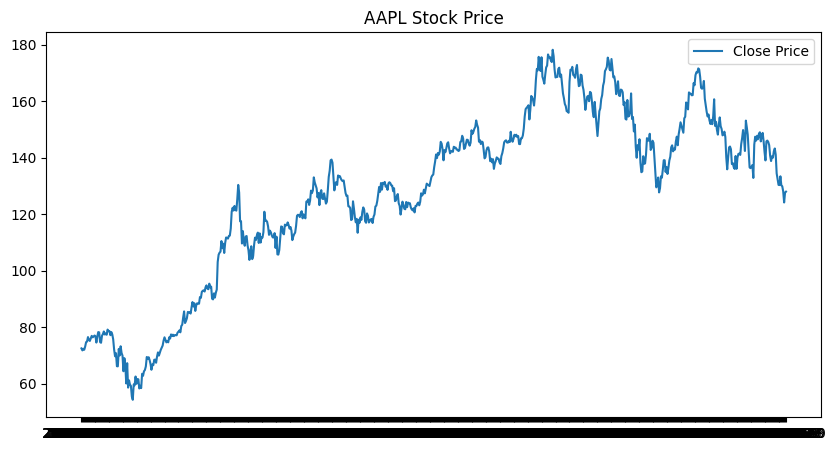

In [2]:
ticker = "AAPL"
start_date = "2020-01-01"
end_date = "2023-01-01"

df = fetch_stock_data(ticker, start_date, end_date)
print(df.head())

plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Close Price')
plt.title(f"{ticker} Stock Price")
plt.legend()
plt.show()

## 2. Preprocessing

In [4]:
seq_len = 60
batch_size = 32
feature_cols = ['Close'] # We only use Close price for univariate forecasting

preprocessor = DataPreprocessor(seq_len=seq_len)
train_ds, test_ds, scaler = preprocessor.fit_transform(df, feature_cols)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_ds)}")
print(f"Test samples: {len(test_ds)}")

Train samples: 544
Test samples: 92


## 3. Model Training

Epoch 1/20, Loss: 0.095964
Epoch 2/20, Loss: 0.024750
Epoch 3/20, Loss: 0.010355
Epoch 4/20, Loss: 0.007886
Epoch 5/20, Loss: 0.007209
Epoch 6/20, Loss: 0.006472
Epoch 7/20, Loss: 0.005093
Epoch 8/20, Loss: 0.004987
Epoch 9/20, Loss: 0.004308
Epoch 10/20, Loss: 0.003908
Epoch 11/20, Loss: 0.003902
Epoch 12/20, Loss: 0.003069
Epoch 13/20, Loss: 0.003409
Epoch 14/20, Loss: 0.002828
Epoch 15/20, Loss: 0.002605
Epoch 16/20, Loss: 0.002497
Epoch 17/20, Loss: 0.002212
Epoch 18/20, Loss: 0.001953
Epoch 19/20, Loss: 0.002006
Epoch 20/20, Loss: 0.002104


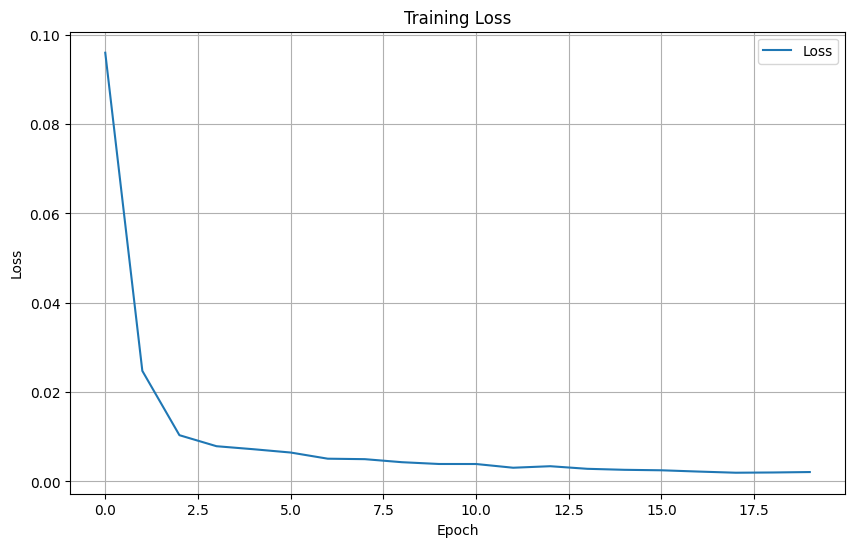

In [5]:
model = XformersTimeSeriesModel(
    input_dim=len(feature_cols),
    d_model=32,
    nhead=2,
    num_layers=2
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

history = train_model(model, train_loader, criterion, optimizer, device, epochs=20)
plot_training_history(history)

## 4. Evaluation

In [6]:
preds_scaled, actuals_scaled = evaluate_model(model, test_loader, device)

# Inverse transform to get real prices
preds = scaler.inverse_transform(preds_scaled)
actuals = scaler.inverse_transform(actuals_scaled)

# Calculate Metrics
mae = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Use our updated plotting function to save if we wanted, but the ARIMA section handles the final plot
# plot_predictions(actuals, preds, save_path="simple_forecast.png")

MAE: 3.2500
RMSE: 4.0744


## 5. Baseline Comparison (ARIMA)

In [7]:
!pip install statsmodels

Training ARIMA Baseline on 604 samples...


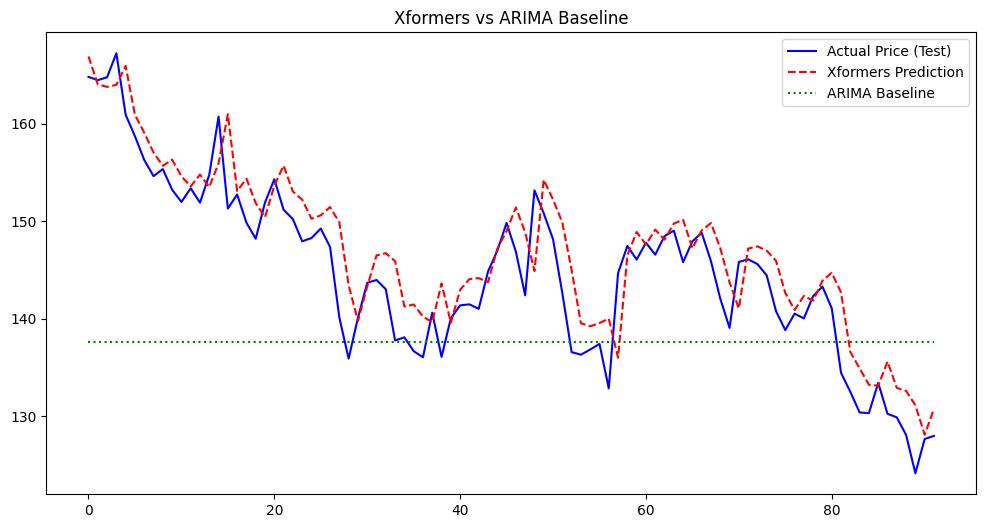

ARIMA MAE: 9.2321
Xformers MAE: 3.2500
Artifacts saved: forecast_close.png, metrics.txt, preds.csv, actual_next_block.csv


In [8]:
from statsmodels.tsa.arima.model import ARIMA

# Train ARIMA on the original train data
train_size = int(len(df) * 0.8)
train_data_raw = df['Close'].values[:train_size]
test_data_raw = df['Close'].values[train_size:]

history = [x for x in train_data_raw]
arima_preds = []

print(f"Training ARIMA Baseline on {len(train_data_raw)} samples...")
# Simple static forecast for the test length
params = (5,1,0)
model_arima = ARIMA(history, order=params)
model_fit = model_arima.fit()

forecast_res = model_fit.get_forecast(steps=len(test_data_raw))
arima_preds = forecast_res.predicted_mean

# Plotting Comparison
# Align x-axis: seq_len offset for Xformers because it consumes seq_len before first prediction
plt.figure(figsize=(12, 6))
plt.plot(actuals, label='Actual Price (Test)', color='blue')
plt.plot(preds, label='Xformers Prediction', color='red', linestyle='--')

# ARIMA makes predictions for all of test_data_raw, but Xformers only for test_data_raw[seq_len:]
# So we slice ARIMA to match the Xformers window
plt.plot(arima_preds[seq_len:], label='ARIMA Baseline', color='green', linestyle=':')

plt.title("Xformers vs ARIMA Baseline")
plt.legend()
plt.savefig("forecast_close.png")
plt.show()

mae_arima = mean_absolute_error(test_data_raw[seq_len:], arima_preds[seq_len:])
print(f"ARIMA MAE: {mae_arima:.4f}")
print(f"Xformers MAE: {mae:.4f}")

# Save Artifacts as per README
with open("metrics.txt", "w") as f:
    f.write(f"RMSE_Close: {rmse:.4f}\n")
    f.write(f"MAE_Xformers: {mae:.4f}\n")
    f.write(f"MAE_ARIMA: {mae_arima:.4f}\n")

pd.DataFrame(preds, columns=['Predicted_Close']).to_csv("preds.csv", index=False)
pd.DataFrame(actuals, columns=['Actual_Close']).to_csv("actual_next_block.csv", index=False)
print("Artifacts saved: forecast_close.png, metrics.txt, preds.csv, actual_next_block.csv")